# Phase 7: Customer Segmentation using K-Means

This notebook continues the pipeline from `03_RFM_Analysis.ipynb`. The RFM feature table
and the fitted scaler are reloaded, and the same log-transform is reapplied to rebuild
the scaled feature matrix used for clustering.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use("default")

In [4]:
rfm = pd.read_csv("../data/rfm_features.csv", index_col="Customer ID")
scaler = joblib.load("../models/scaler.pkl")

rfm_log = rfm.copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_scaled = scaler.transform(rfm_log)

print("Loaded RFM features:", rfm.shape)
rfm.head()

Loaded RFM features: (5878, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


# Phase 7: Customer Segmentation using K-Means

## Objective

The objective of this phase is to group customers with similar purchasing behavior based on their RFM characteristics.

Since K-Means requires the number of clusters as an input, two evaluation techniques are used:

- **Elbow Method:** Measures the Within-Cluster Sum of Squares (WCSS) to identify the point where adding more clusters provides diminishing returns.
- **Silhouette Score:** Measures how well-separated the resulting clusters are. Higher values indicate better-defined clusters.

Using both methods helps select an appropriate number of customer segments before training the final model.

In [5]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

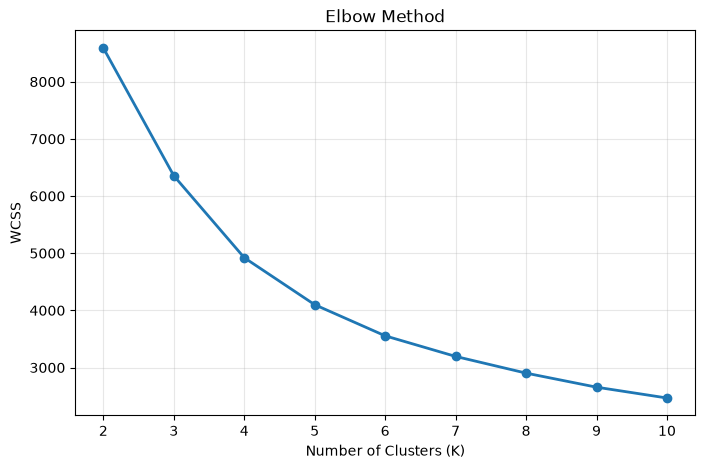

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.show()

In [7]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    scores.append(score)

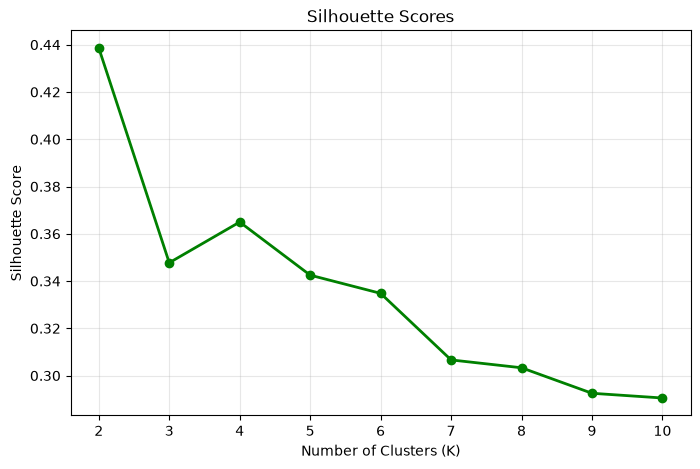

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Silhouette Scores")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(alpha=0.3)

plt.show()

In [9]:
for k, score in zip(range(2,11), scores):
    print(f"K={k}  -->  {score:.4f}")

K=2  -->  0.4386
K=3  -->  0.3477
K=4  -->  0.3650
K=5  -->  0.3425
K=6  -->  0.3348
K=7  -->  0.3066
K=8  -->  0.3033
K=9  -->  0.2925
K=10  -->  0.2905


## Choosing the Optimal Number of Clusters

The optimal number of clusters was determined using both the Elbow Method and the Silhouette Score.

### Elbow Method
The WCSS curve shows a noticeable bend around **K = 4**, indicating that additional clusters provide only marginal improvements.

### Silhouette Score
Although the highest Silhouette Score is obtained for **K = 2**, this solution creates only two broad customer groups, limiting its business usefulness.

The Silhouette Score for **K = 4** remains relatively high while providing more meaningful customer segmentation.

### Final Decision

Based on both quantitative evaluation and business interpretability, **4 clusters** were selected for the final K-Means model.

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [11]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,2
12348.0,75,5,2019.40,3
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [12]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

In [13]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]]
       .mean()
       .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,394.95,1.38,317.08
1,28.30,3.05,857.49
2,27.71,19.28,10731.16
3,230.07,5.06,1948.50


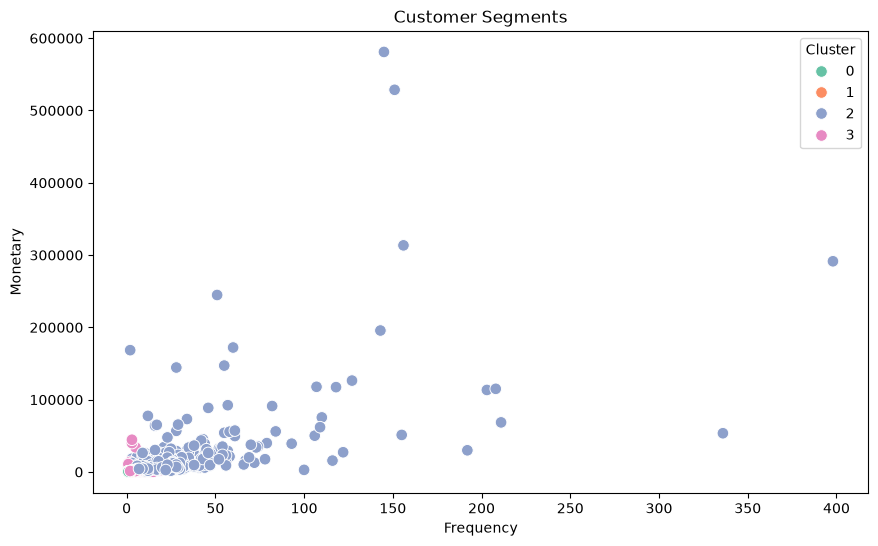

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segments")
plt.show()

### Note

The scatter plot above is difficult to interpret because a small number of high-Monetary outliers compress the rest of the points into one corner of the chart. The cluster profile table below (mean/median/count per cluster) gives a clearer, more reliable comparison than the raw scatter plot.

In [15]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
       .agg(["mean", "median", "count"])
       .round(2)
)

cluster_profile

Recency              Frequency               Monetary               
           mean median count      mean median count      mean   median count
Cluster                                                                     
0        394.95  402.0  1973      1.38    1.0  1973    317.08   273.31  1973
1         28.30   24.0  1250      3.05    3.0  1250    857.49   734.12  1250
2         27.71   17.0  1196     19.28   13.0  1196  10731.16  4986.12  1196
3        230.07  186.0  1459      5.06    4.0  1459   1948.50  1450.04  1459

# Phase 7.3: Customer Segment Interpretation

## Cluster 0 – Lost Customers

- High Recency
- Very Low Frequency
- Very Low Monetary Value

These customers have not purchased for a long period and contribute minimal revenue. They are likely inactive and suitable for targeted re-engagement campaigns.

---

## Cluster 1 – Regular Customers

- Low Recency
- Moderate Frequency
- Moderate Spending

These customers are active and contribute consistently to business revenue. Loyalty programs and personalized recommendations can encourage more frequent purchases.

---

## Cluster 2 – VIP Customers

- Low Recency
- Highest Frequency
- Highest Monetary Value

These customers represent the most valuable customer segment. They should be prioritized through premium services, exclusive offers, and retention initiatives.

---

## Cluster 3 – At-Risk Customers

- Moderate to High Recency
- Moderate Frequency
- Good Monetary Value

These customers were previously engaged but have not purchased recently. Personalized retention campaigns can help reactivate them before they become inactive.

#### Q1) How many customers belong to each segment?

In [16]:
# Cluster IDs from K-Means are arbitrary and can shift between runs/retrains.
# Instead of hardcoding {0: "Lost Customers", ...}, characterize each cluster
# by its RFM profile and assign labels programmatically. This keeps the
# mapping correct even if cluster order changes later.

cluster_stats = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

# Rank clusters by monetary value (desc) and recency (asc) to build a value score
cluster_stats["value_score"] = (
    cluster_stats["Monetary"].rank(ascending=False)
    + cluster_stats["Frequency"].rank(ascending=False)
    + cluster_stats["Recency"].rank(ascending=True)
)

ordered_clusters = cluster_stats.sort_values("value_score").index.tolist()
segment_labels = ["VIP Customers", "Regular Customers", "At-Risk Customers", "Lost Customers"]
segment_map = dict(zip(ordered_clusters, segment_labels))

print("Cluster -> Segment mapping:", segment_map)

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

Cluster -> Segment mapping: {2: 'VIP Customers', 3: 'Regular Customers', 1: 'At-Risk Customers', 0: 'Lost Customers'}


,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,2,VIP Customers
12347.0,2,8,4921.53,2,VIP Customers
12348.0,75,5,2019.40,3,Regular Customers
12349.0,19,4,4428.69,1,At-Risk Customers
12350.0,310,1,334.40,0,Lost Customers


In [17]:
segment_count = rfm["Segment"].value_counts()

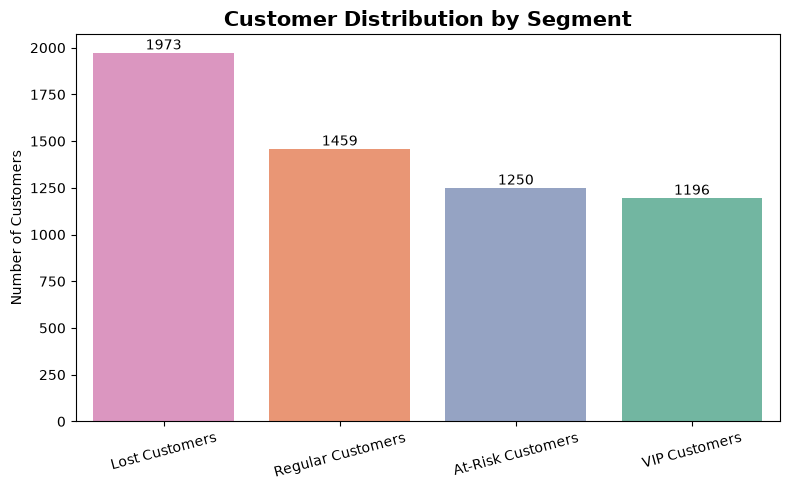

In [18]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=rfm,
    x="Segment",
    order=segment_count.index,
    hue="Segment",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Segment", fontsize=15, fontweight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#### Q2) Which segment generates the most revenue?

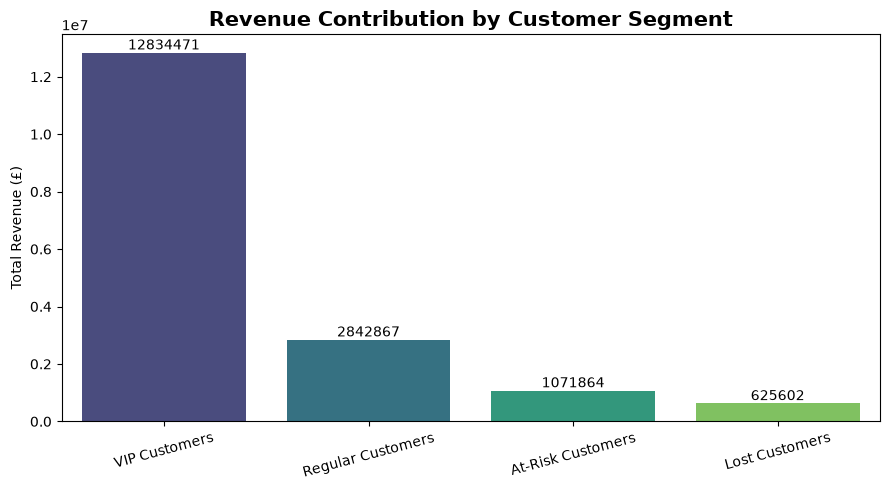

In [19]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values,
    hue=segment_revenue.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue Contribution by Customer Segment",
          fontsize=15,
          fontweight="bold")

plt.xlabel("")
plt.ylabel("Total Revenue (£)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Q3) What percentage of customers belong to each segment?

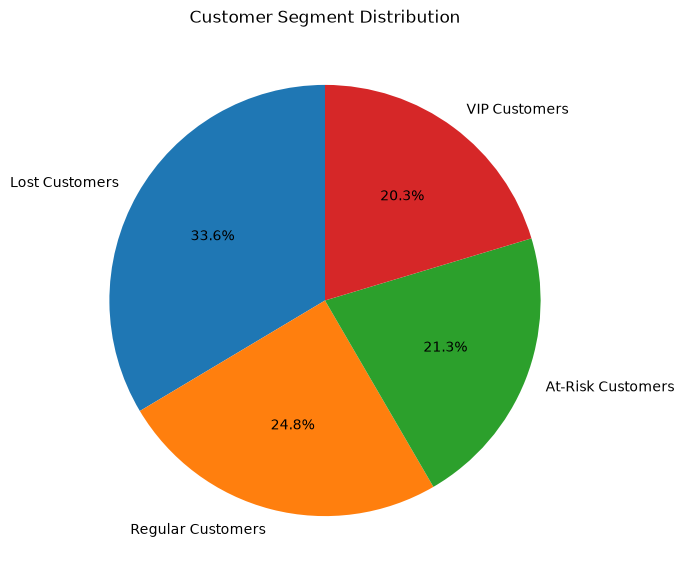

In [20]:
segment_percent = (
    rfm["Segment"].value_counts(normalize=True) * 100
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_percent.values,
    labels=segment_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segment Distribution")
plt.show()

#### Executive Summary

In [21]:
segment_summary = (
    rfm.groupby("Segment")
       .agg({
           "Recency":"mean",
           "Frequency":"mean",
           "Monetary":["mean","sum","count"]
       })
       .round(2)
)

segment_summary

Recency Frequency  Monetary                   
                     mean      mean      mean          sum count
Segment                                                         
At-Risk Customers   28.30      3.05    857.49   1071864.29  1250
Lost Customers     394.95      1.38    317.08    625601.80  1973
Regular Customers  230.07      5.06   1948.50   2842867.24  1459
VIP Customers       27.71     19.28  10731.16  12834470.94  1196

# Phase 8: Retention Analysis

## Executive Summary

The customer base was successfully segmented into four groups based on Recency, Frequency, and Monetary (RFM) characteristics.

### Key Findings

- Lost Customers represent the largest customer segment.
- VIP Customers generate the highest revenue despite being a smaller proportion of the customer base.
- At-Risk Customers present an important opportunity for retention campaigns.
- Regular Customers contribute stable revenue and should be nurtured through loyalty initiatives.

The segmentation enables the business to allocate marketing resources more effectively and personalize customer engagement strategies.

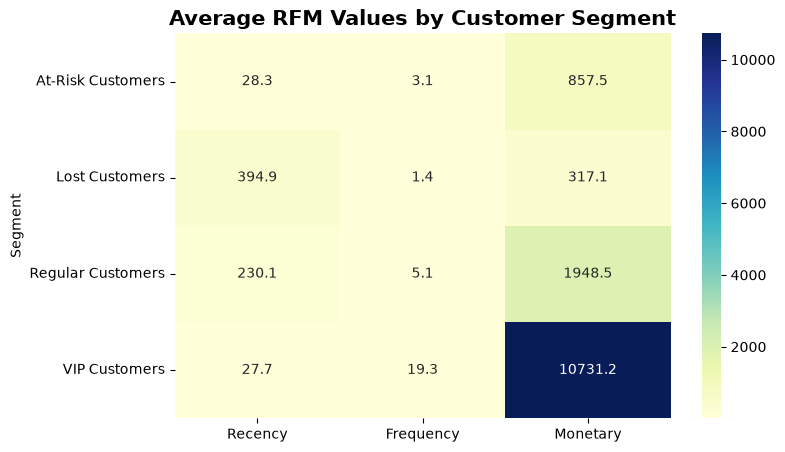

In [22]:
cluster_profile = (
    rfm.groupby("Segment")[["Recency","Frequency","Monetary"]]
       .mean()
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average RFM Values by Customer Segment",
          fontsize=15,
          fontweight="bold")

plt.show()

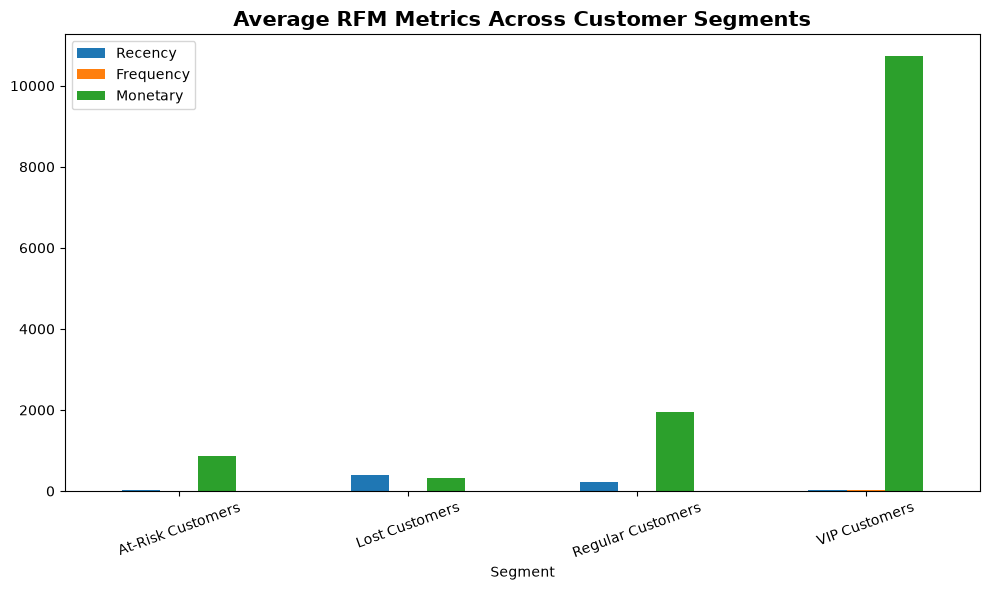

In [23]:
cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average RFM Metrics Across Customer Segments",
          fontsize=15,
          fontweight="bold")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Business Recommendations

Based on the customer segmentation analysis, the following business strategies are recommended.

| Customer Segment | Business Strategy |
|------------------|-------------------|
| VIP Customers | Reward loyalty through exclusive memberships, premium support, and early access to new products. |
| Regular Customers | Encourage repeat purchases using loyalty programs and personalized product recommendations. |
| At-Risk Customers | Launch targeted retention campaigns, reminder emails, and limited-time offers. |
| Lost Customers | Implement win-back campaigns with promotional discounts or reactivation offers. |

These strategies enable businesses to optimize marketing resources by targeting customers according to their purchasing behavior.

In [24]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.pkl")

['../models/kmeans_model.pkl']

In [25]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [26]:
rfm = rfm.reset_index()          # Customer ID becomes a column
rfm = rfm.rename(columns={
    "Customer ID": "CustomerID"
})

print(rfm.columns)               # Verify
rfm.to_csv("../data/customer_segments.csv", index=False)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')


In [27]:
check = pd.read_csv("../data/customer_segments.csv")
print(check.columns)
print(check.head())

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')
   CustomerID  Recency  Frequency  Monetary  Cluster            Segment
0     12346.0      326         12  77556.46        2      VIP Customers
1     12347.0        2          8   4921.53        2      VIP Customers
2     12348.0       75          5   2019.40        3  Regular Customers
3     12349.0       19          4   4428.69        1  At-Risk Customers
4     12350.0      310          1    334.40        0     Lost Customers


In [28]:
from pathlib import Path

print(Path("../data/customer_segments.csv").resolve())

C:\Users\HP\Desktop\Customer\data\customer_segments.csv


In [29]:
loaded_model = joblib.load("../models/kmeans_model.pkl")

loaded_scaler = joblib.load("../models/scaler.pkl")